Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2956 entries, 0 to 2955
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2956 non-null   object 
 1   Open       2956 non-null   float64
 2   High       2956 non-null   float64
 3   Low        2956 non-null   float64
 4   Close      2956 non-null   float64
 5   Adj Close  2956 non-null   float64
 6   Volume     2956 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 161.8+ KB
None

Checking for missing values:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64


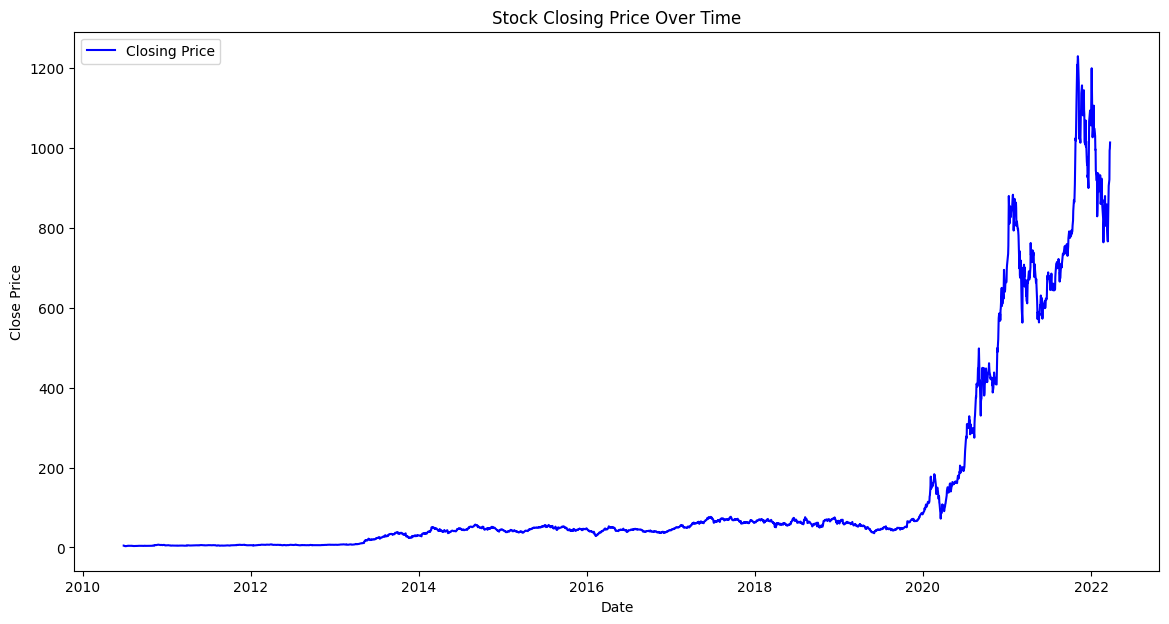

C:\Users\Farhang\Documents\Maastricht University\Thesis\Code\.venv\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 76904.9688 - val_loss: 75590.9531
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 75136.0391 - val_loss: 69359.3594
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 68147.2031 - val_loss: 62498.8125
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 59168.7930 - val_loss: 54672.6055
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 52785.2734 - val_loss: 46456.5977
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 48618.1250 - val_loss: 38227.5195
Epoch 7/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 36341.3008 - val_loss: 30312.0645
Epoch 8/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 27099.7188 - val_loss: 23508.1113
Epoch 9/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 22579.5137 - val_loss: 17965.1523
Epoch 10/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 18102.7148 - val_loss: 13424.0303
Epoch 11/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 12700.111

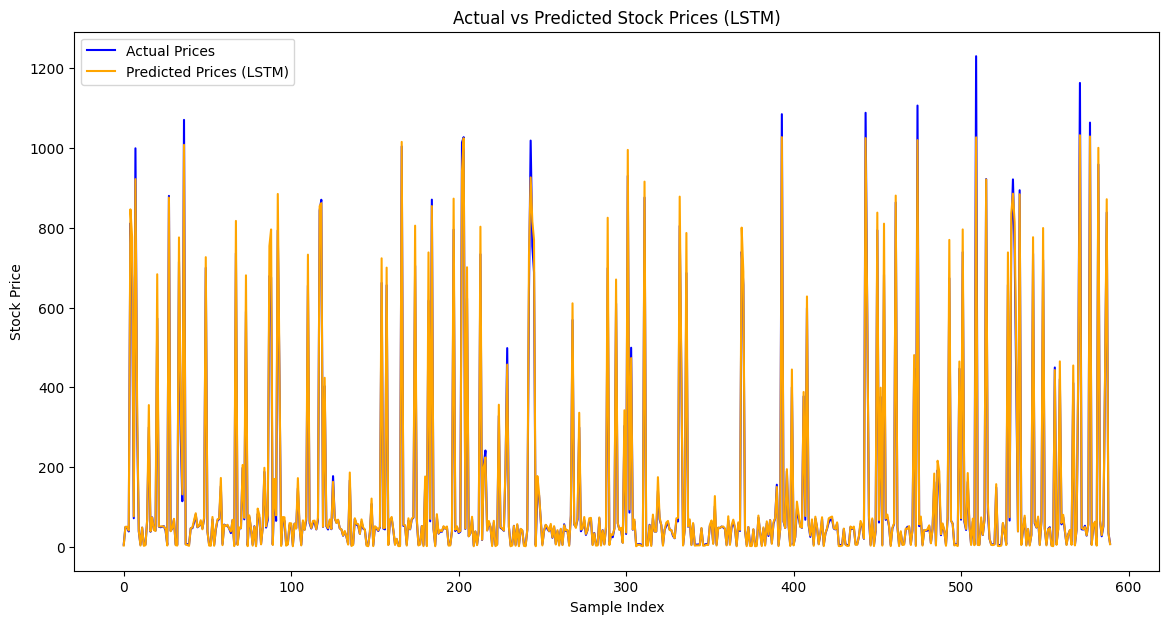

Random Forest Model - RMSE: 9.804852845007643, R2: 0.9984315628855099


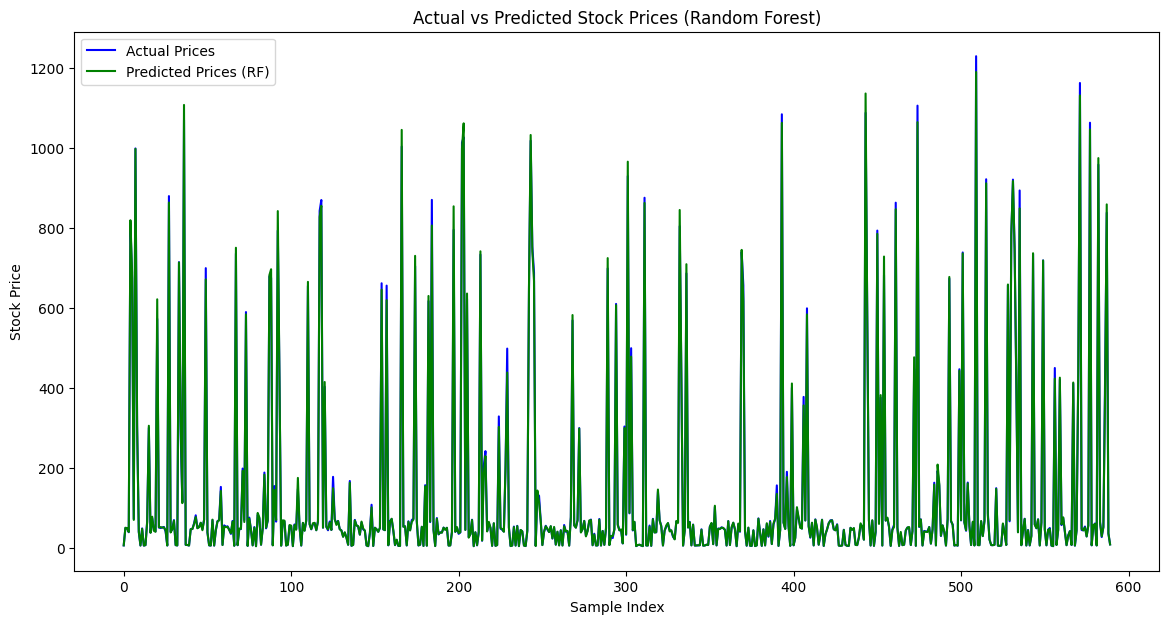

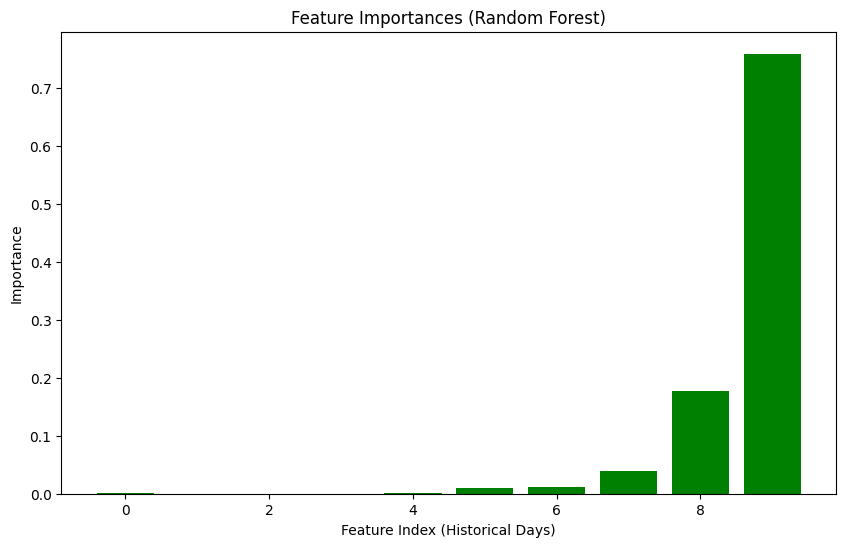


Model Comparison:
LSTM Model - RMSE: 25.9276717399564, R2: 0.9890323902269712
Random Forest Model - RMSE: 9.804852845007643, R2: 0.9984315628855099


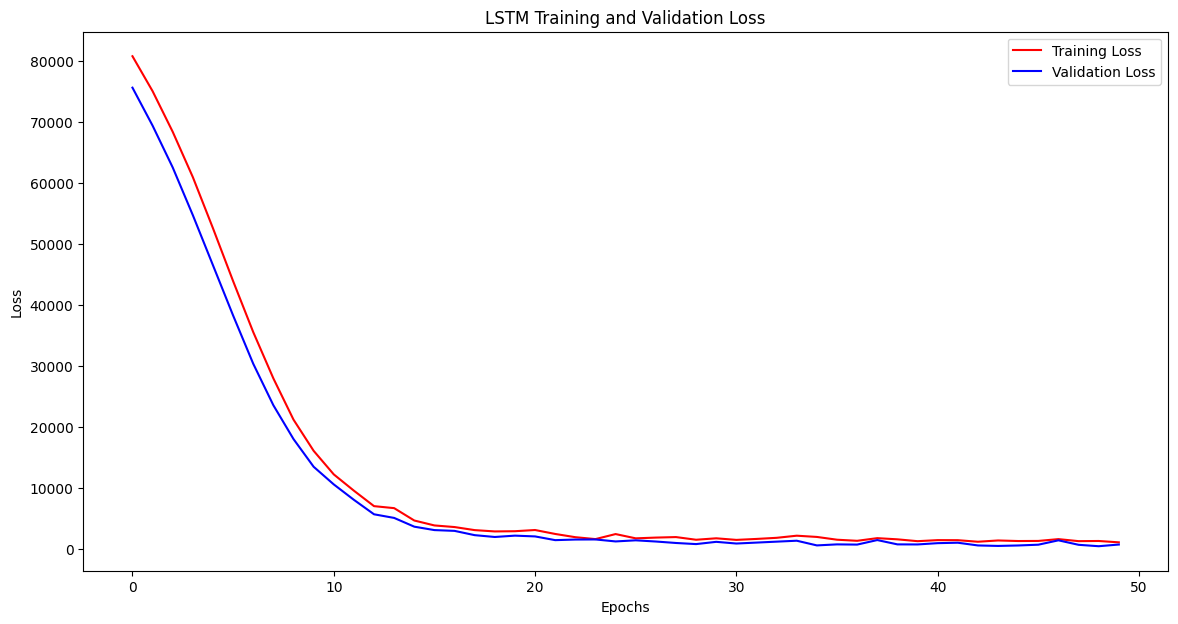

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from datetime import datetime
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

# Load the data
data = pd.read_csv('Data/TSLA.csv')

# Display basic info and check for missing values
print("Dataset Info:")
print(data.info())
print("\nChecking for missing values:")
print(data.isnull().sum())

# Ensure the 'Date' column is a datetime type if it exists
if 'Date' in data.columns:
    data['Date'] = pd.to_datetime(data['Date'])
    data.set_index('Date', inplace=True)

# Plot the closing price to visualize trends
plt.figure(figsize=(14, 7))
plt.plot(data['Close'], label='Closing Price', color='blue')
plt.title('Stock Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

# Handle missing values (if any)
data = data.dropna()

# Feature Engineering: Use historical data to create features
window_size = 10
features = []
targets = []

for i in range(window_size, len(data)):
    features.append(data['Close'].iloc[i-window_size:i].values)
    targets.append(data['Close'].iloc[i])

features = np.array(features)
targets = np.array(targets)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(features, targets, test_size=0.2, random_state=42)

# Reshape data for LSTM model
X_train_lstm = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_lstm = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

# Build an LSTM model
model_lstm = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(X_train_lstm.shape[1], 1)),
    Dropout(0.2),
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    Dense(units=25, activation='relu'),
    Dense(units=1)
])

# Compile the model
model_lstm.compile(optimizer='adam', loss='mean_squared_error')

# Train the LSTM model
history = model_lstm.fit(X_train_lstm, y_train, epochs=50, batch_size=32, validation_data=(X_test_lstm, y_test), verbose=1)

# Evaluate the LSTM model
y_pred_lstm = model_lstm.predict(X_test_lstm)
rmse_lstm = np.sqrt(mean_squared_error(y_test, y_pred_lstm))
r2_lstm = r2_score(y_test, y_pred_lstm)
print(f'LSTM Model - RMSE: {rmse_lstm}, R2: {r2_lstm}')

# Plot LSTM model results
plt.figure(figsize=(14, 7))
plt.plot(y_test, label='Actual Prices', color='blue')
plt.plot(y_pred_lstm, label='Predicted Prices (LSTM)', color='orange')
plt.title('Actual vs Predicted Stock Prices (LSTM)')
plt.xlabel('Sample Index')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

# Random Forest Model for comparison
scaler = StandardScaler()
X_train_rf = scaler.fit_transform(X_train)
X_test_rf = scaler.transform(X_test)

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train_rf, y_train)

# Make predictions with Random Forest
y_pred_rf = model_rf.predict(X_test_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
print(f'Random Forest Model - RMSE: {rmse_rf}, R2: {r2_rf}')

# Plot Random Forest results
plt.figure(figsize=(14, 7))
plt.plot(y_test, label='Actual Prices', color='blue')
plt.plot(y_pred_rf, label='Predicted Prices (RF)', color='green')
plt.title('Actual vs Predicted Stock Prices (Random Forest)')
plt.xlabel('Sample Index')
plt.ylabel('Stock Price')
plt.legend()
plt.show()

# Feature Importance Analysis (Random Forest)
importances = model_rf.feature_importances_
plt.figure(figsize=(10, 6))
plt.bar(range(window_size), importances, color='green')
plt.title('Feature Importances (Random Forest)')
plt.xlabel('Feature Index (Historical Days)')
plt.ylabel('Importance')
plt.show()

# Compare models
print("\nModel Comparison:")
print(f"LSTM Model - RMSE: {rmse_lstm}, R2: {r2_lstm}")
print(f"Random Forest Model - RMSE: {rmse_rf}, R2: {r2_rf}")

# Plot Training Loss for LSTM
plt.figure(figsize=(14, 7))
plt.plot(history.history['loss'], label='Training Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()